In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, learning_curve, cross_val_score
from sklearn.feature_selection import SelectFromModel

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = '/content/drive/MyDrive/Machine Learning/KNN/Lab_Exercise/german.data-numeric'
credit = np.genfromtxt(data_path)
X, y = credit[:, :-1], credit[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# RF & DT baseline


In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"RF Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(f"RF F1 Score: {f1_score(y_test, y_pred_rf)}")
print(f"RF AUC: {roc_auc_score(y_test, y_pred_rf)}")

RF Accuracy: 0.81
RF F1 Score: 0.875
RF AUC: 0.7173939175381656


In [ ]:
# criterion='gini',  # độ đo chất lượng gini / entropy
# splitter='best',
# max_depth=None,     # độ sâu của cây
# min_samples_split=2, # số mẫu tối thiểu để tiếp tục phân chia
# min_samples_leaf=1, # số lá tối thiểu
# max_features=None,  # số thuộc tính tối đa
# max_leaf_nodes=None, # số lá tối đa
# min_impurity_decrease=0.0,
# min_impurity_split=None

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"dt Accuracy: {accuracy_score(y_test, y_pred_dt)}")
print(f"dt F1 Score: {f1_score(y_test, y_pred_dt)}")
print(f"dt AUC: {roc_auc_score(y_test, y_pred_dt)}")

dt Accuracy: 0.665
dt F1 Score: 0.7632508833922261
dt AUC: 0.5948431301839163


# Tìm kiếm siêu tham số

In [ ]:
def grid_search(algorithm, n_jobs, dict_param):
  if algorithm == 'decision-tree':
    model = DecisionTreeClassifier()
  elif algorithm == 'random-forest':
    model = RandomForestClassifier()
  classifier = GridSearchCV(model, dict_param, cv=5, n_jobs=n_jobs, scoring='accuracy')
  classifier.fit(X_train, y_train)
  print('Best model:', end='')
  print(classifier.best_estimator_)
  return classifier.best_estimator_

def evaluate(model):
  print(f"Accuracy: {accuracy_score(y_train, model.predict(X_train))}")
  print(f"F1 Score: {f1_score(y_train, model.predict(X_train))}")
  print(f"AUC: {roc_auc_score(y_train, model.predict(X_train))}")
  print("Train confision matrix: ")
  print(confusion_matrix(y_train, model.predict(X_train)))
  print("-" * 50)
  y_pred = model.predict(X_test)
  print(f"Test Accuracy: {accuracy_score(y_test, y_pred)}")
  print(f"Test F1 Score: {f1_score(y_test, y_pred)}")
  print(f"Test AUC: {roc_auc_score(y_test, y_pred)}")
  print("Test confision matrix: ")
  print(confusion_matrix(y_test, y_pred))

def plot_learning_curve(estimator, title, label_curve, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5), new_plot=False):
    if new_plot:
      plt.title(title)
      plt.xlabel("Training example")
      plt.ylabel("Score")
      plt.grid()

    if ylim is not None:
      plt.ylim(*ylim)

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.plot(train_sizes, test_scores_mean, 'o-', color='r', label=label_curve['test'])
    plt.plot(train_sizes, train_scores_mean, 'o-', color='g', label=label_curve['train'])
    plt.legend(loc="best")
    return plt

Text(0.5, 1.0, 'DT validation curve for max_depth')

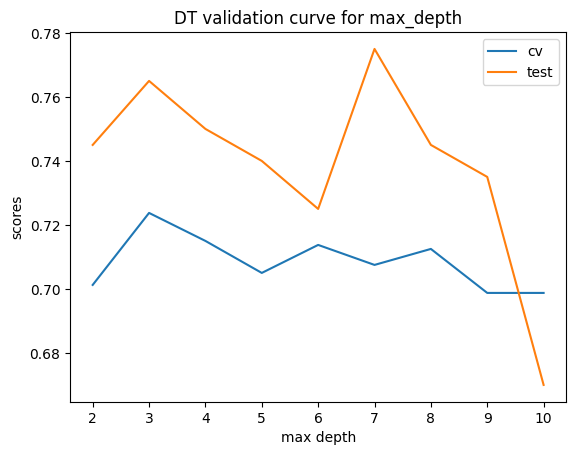

In [ ]:
cv_accuracies_by_depth, test_accuracies_by_depth = [], []
max_depth_values = np.arange(2, 11)

for curr_max_depth in max_depth_values:
  dt = DecisionTreeClassifier(random_state=42, max_depth=curr_max_depth)
  val_scores = cross_val_score(estimator=dt, X=X_train, y=y_train, cv=5, scoring='accuracy')
  cv_accuracies_by_depth.append(val_scores.mean())

  dt.fit(X_train, y_train)
  cur_pred = dt.predict(X_test)
  test_accuracies_by_depth.append(accuracy_score(y_test, cur_pred))

plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')

In [ ]:
dict_params = {
    'max_depth': [2,3,5,7,10,20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_dt = grid_search('decision-tree', n_jobs=-1, dict_param=dict_params)


Best model:DecisionTreeClassifier(max_depth=5, min_samples_leaf=20)


In [ ]:
# feature_importance

importances = best_dt.feature_importances_
indices = np.argsort(importances)[::-1]
print("Top 10 feature importance: ")
for i in range(10):
  print(f"Feature {i} - {importances[indices[i]]}")

Top 10 feature importance: 
Feature 0 - 0.40445005922715943
Feature 1 - 0.17066428015343657
Feature 2 - 0.14261352910286315
Feature 3 - 0.07120344185816782
Feature 4 - 0.05428847945598893
Feature 5 - 0.05400258515142507
Feature 6 - 0.04007488290946428
Feature 7 - 0.03813781829612112
Feature 8 - 0.015091674891623292
Feature 9 - 0.009473248953750433


In [ ]:
dict_param = {
    'max_depth': [3, 11, 15, 24, 27],
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features':  [4, 6, 10, 16],
    'n_estimators': [50, 75]
}
best_rf = grid_search('random-forest', n_jobs=-1, dict_param=dict_param)

Best model:RandomForestClassifier(max_depth=27, max_features=4, min_samples_leaf=7,
                       n_estimators=75)


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [ ]:
# Bỏ đi feature có độ quan trọng thấp hơn
sfm = SelectFromModel(best_rf, threshold='mean')
sfm.fit(X_train, y_train)
X_train = sfm.transform(X_train)
X_test = sfm.transform(X_test)
forest_dropped = RandomForestClassifier(n_estimators=50, max_depth=11, max_features=10,min_samples_leaf=5, n_jobs=-1, random_state=42)
forest_dropped.fit(X_train, y_train)
y_pred = forest_dropped.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")
print(f"AUC: {roc_auc_score(y_test, y_pred)}")

Accuracy: 0.79
F1 Score: 0.8618421052631579
AUC: 0.6933525664142326


# RF khi gặp class Imbalance

In [ ]:
best_forest = RandomForestClassifier(max_depth=27, max_features=4, min_samples_leaf=7,
                       n_estimators=75, n_jobs=-1, random_state=42)
best_forest.fit(X_train, y_train)
evaluate(best_forest)

Accuracy: 0.84875
F1 Score: 0.8978902953586498
AUC: 0.7808289847757184
Train confision matrix: 
[[532  27]
 [ 94 147]]
--------------------------------------------------
Test Accuracy: 0.795
Test F1 Score: 0.8673139158576052
Test AUC: 0.6870417117442
Test confision matrix: 
[[134   7]
 [ 34  25]]


In [ ]:
rf1 = RandomForestClassifier(max_depth=27, max_features=4, min_samples_leaf=7,
                       n_estimators=75, n_jobs=-1, random_state=42, class_weight="balanced")
rf1.fit(X_train, y_train)
evaluate(rf1)

Accuracy: 0.83875
F1 Score: 0.8802228412256268
AUC: 0.8326850704058076
Train confision matrix: 
[[474  85]
 [ 44 197]]
--------------------------------------------------
Test Accuracy: 0.795
Test F1 Score: 0.8487084870848709
Test AUC: 0.7806827743719197
Test confision matrix: 
[[115  26]
 [ 15  44]]


In [ ]:
rf2 = RandomForestClassifier(max_depth=27, max_features=4, min_samples_leaf=7,
                       n_estimators=75, n_jobs=-1, random_state=42, class_weight="balanced_subsample")
rf2.fit(X_train, y_train)
evaluate(rf2)

Accuracy: 0.83125
F1 Score: 0.8744186046511628
AUC: 0.8249578752811406
Train confision matrix: 
[[470  89]
 [ 46 195]]
--------------------------------------------------
Test Accuracy: 0.8
Test F1 Score: 0.8529411764705882
Test AUC: 0.7842288736626999
Test confision matrix: 
[[116  25]
 [ 15  44]]


In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
rf2 = BalancedRandomForestClassifier(max_depth=27, max_features=4, min_samples_leaf=7,
                       n_estimators=75, n_jobs=-1, random_state=4)
rf2.fit(X_train, y_train)
evaluate(rf2)

/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/usr/local/lib/python3.10/dist-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


Accuracy: 0.775
F1 Score: 0.8255813953488372
AUC: 0.7835271936400953
Train confision matrix: 
[[426 133]
 [ 47 194]]
--------------------------------------------------
Test Accuracy: 0.735
Test F1 Score: 0.792156862745098
Test AUC: 0.7479865368433707
Test confision matrix: 
[[101  40]
 [ 13  46]]
